<a href="https://colab.research.google.com/github/waralimachi066-create/Teste_Analytics_Wara-Limachi_/blob/Python/Tarefa_Parte%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,ID,Data,Produto,Categoria,Quantidade,Preço
0,1,2023-07-18,Livro,Material,1,103.07
1,2,2023-07-14,Colar,Bijuteria,1,121.73
2,3,2023-12-25,Fone,Acessório,7,118.17
3,4,2023-08-28,Batom,Maquiagem,9,54.59
4,5,2023-09-08,Livro,Material,4,164.00
5,6,2023-02-10,Fone,Acessório,4,35.85
6,7,2023-08-01,Batom,Maquiagem,4,192.09
7,8,2023-02-05,Fone,Acessório,5,170.96
8,9,2023-06-03,Batom,Maquiagem,8,149.53
9,10,2023-04-14,Colar,Bijuteria,1,139.75


_____________________________________________________________________________
Valores faltantes: ID            0
Data          0
Produto       0
Categoria     0
Quantidade    0
Preço         0
dtype: int64
Tabela limpa e salva!
_____________________________________________________________________________
Total de vendas por produto: Produto
Batom    12002.64
Colar     4000.15
Fone      5903.24
Livro     4763.82
Mouse     1641.13
Name: preço_total, dtype: float64
_____________________________________________________________________________
O produto mais vendido no valor foi o: Batom
_____________________________________________________________________________
Gráfico gerado e salvo!


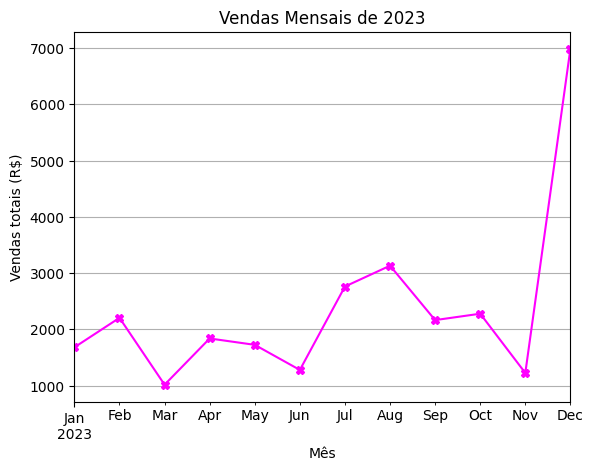

In [ ]:
import pandas as pd #Manipulação de tabelas
import numpy as np #Cálculos matemáticos e sementes de sorteio
import random #Itens aleatórios
import matplotlib.pyplot as plt #Desenhar o gráfico
from datetime import datetime, timedelta #Manuseio do calendário
import sqlite3 #Import novo!

np.random.seed(7) #Definimos para a semente o 7, assim em qualquer computador a resposta será a mesma

def dados_vendas(registros=50): #Criamos uma função para simular o script de vendas
    produtos = ['Livro', 'Batom', 'Mouse', 'Fone', 'Colar']
    categorias = ['Material', 'Maquiagem', 'Informática', 'Acessório', 'Bijuteria']
    dados = []
    data = datetime(2023, 1, 1) #Configuramos para o primeiro dia de 2023

    for i in range(registros):
        escolha = random.randint(0, len(produtos)-1) #Sorteamos um índice e subtraimos -1, para não dar erro pois o 0 já é contado como o livro
        data_venda = data + timedelta(days=random.randint(0, 364)) #Somamos dias aleatórios à data

        dados.append({ #Criamos um dicionário e essa será o cabeçalho da nossa tabela
            'ID': i + 1,
            'Data': data_venda,
            'Produto': produtos[escolha],
            'Categoria': categorias[escolha],
            'Quantidade': random.randint(1, 10),
            'Preço': round(random.uniform(20, 200), 2) #Preço entre 20 e 1000 que vai gerar um número float apenas com duas casas deciamis, mesmo que a entrada seja um inteiro
            })
    return pd.DataFrame(dados) #Transformamos a lista em uma tabela

tabela = dados_vendas(50)
display(tabela)
print("_____________________________________________________________________________")

print("Valores faltantes:", tabela.isnull().sum()) #Verificamos se há valores nulos
tabela = tabela.drop_duplicates() #Tirando linhas duplicadas
tabela['Data'] = pd.to_datetime(tabela['Data']) #Vai ser lido como uma data

tabela.to_csv('data_clean.csv', index=False) #Salvamos a tabela limpa em um arquivo CSV
print("Tabela limpa e salva!")
print("_____________________________________________________________________________")

tabela['preço_total'] = tabela['Quantidade'] * tabela['Preço'] #Criamos uma coluna para o preço total de todas as vendas do produto
venda_por_produto = tabela.groupby('Produto')['preço_total'].sum() #Na coluna criada, vamos somar todos os valores dos 50 registros
print(f"Total de vendas por produto:",venda_por_produto)
print("_____________________________________________________________________________")

venda_por_produto = tabela.groupby('Produto')['preço_total'].sum()
produto_mais_vendido = venda_por_produto.idxmax()
print(f"O produto mais vendido no valor foi o: {produto_mais_vendido}")
tabela.to_csv('produto_mais_vendido.csv', index=False) #Salvamos a tabela limpa em um arquivo CSV
print("_____________________________________________________________________________")

banco_dados = sqlite3.connect('vendas_final.db') #Vamos criar o arquivo de banco de dados! NOVOO
tabela[['ID', 'Data', 'Produto', 'Categoria', 'Quantidade', 'Preço', 'preço_total']].to_sql('Vendas', banco_dados,if_exists='replace', index=False)
banco_dados.close()#Para fechar o "caderno"


tabela['Mes'] = tabela['Data'].dt.to_period('M') #Criamos a nova coluna em meses
vendas_mensais = tabela.groupby('Mes')['preço_total'].sum()#Fazemos a soma por mês

vendas_mensais.plot(linestyle= '-', marker='X', color='magenta')
plt.title('Vendas Mensais de 2023') #Título do gráfico
plt.xlabel('Mês') #Eixo X
plt.ylabel('Vendas totais (R$)') #Eixo Y
plt.grid(True) #Linhas de grade
plt.savefig('grafico_vendas.png') #Salvamos a imagem do gráfico
print("Gráfico gerado e salvo!")
